# CIFAR-10 Image Classification

The CIFAR-10 is a computer visioin dataset that contains 60,000 32x32 color images across 10 classes (6,000 images per class). The categories are: airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks.


# Problem Definition

Given an image from the dataset, predict its class.


# Solution Strategy

The overall idea is to use CNN(convolutional neural network) architecture for the model to classify the images from the dataset.




In [1]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys #os - to communicate with operating system,  sys - to talk with our python interpreter
if sys.version_info[0] == 2: # checking what python version is used and if needed the correct one is uploaded
    from urllib import urlretrieve
    import cPickle as pickle # needed for serialising the objects

else:
    from urllib.request import urlretrieve
    import pickle

# idea: load data that was previously saved using pickle into a binary file
def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

1. Import required libraries.

2. Check whether the code is running under Python 2 or Python 3 and import the appropriate modules.

3. Import pickle to read serialized CIFAR data stored in binary files.

4. Define a helper function to load CIFAR batch files from disk.

5. Download and extract the CIFAR-10 dataset if it is not already available locally.

6. Load the dataset, reshape and normalize the images, split the training part into training and validation sets, and return the train, validation, and test data.


In [2]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K # high-level neural network API on top of tensorflow
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [3]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Dataset not found. Downloading...


/tmp/ipykernel_542/1355624772.py:42: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall(path=path)


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


# Data Visualization

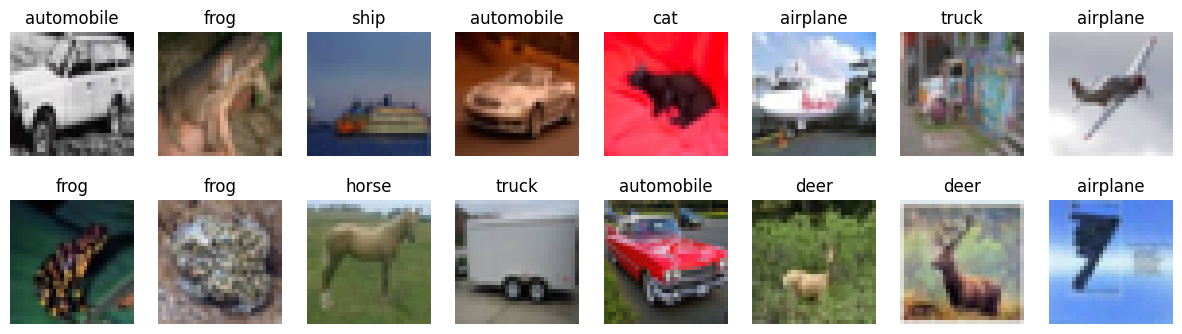

In [4]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [5]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (10, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

## Idea behind one-hot encoding:

These are the lables from the CIFAR-10 dataset  

```
0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck
```
one-hot encoding is mapping each of these numbers into a vector so the model can work with it

For example :
```
0 -> [1,0,0,0,0,0,0,0,0,0]
1 -> [0,1,0,0,0,0,0,0,0,0]
...
```

In [6]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from keras.layers import LeakyReLU

# Model Architecture Overview

This CNN learns by passing each image through convolutional filters that detect simple patterns such as edges, corners, and color contrasts. As the image goes deeper through the network, later convolution layers combine these simple patterns into more complex features such as shapes, textures, and object parts. Max-pooling reduces the spatial size of the feature maps, which helps the model keep the most important information while making computation cheaper. Dropout and data augmentation help prevent overfitting by forcing the model to generalize instead of memorizing the training images. Finally, the dense layers use the extracted features to assign probabilities to the 10 CIFAR-10 classes, and training adjusts all weights to reduce classification error.





In [7]:
from tensorflow.keras import regularizers

def make_model():
    """
    Define CNN architecture for CIFAR-10.
    Returns:
        keras.Sequential model
    """

    input_shape = (32, 32, 3)
    l2_reg = regularizers.l2(1e-4)

    data_augmentation = keras.Sequential([
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomTranslation(0.1, 0.1),
        keras.layers.RandomRotation(0.05),
        keras.layers.RandomZoom(0.1),
    ], name="data_augmentation")

    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),

        # Data augmentation
        data_augmentation,

        # Block 1
        keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                            kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                            kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Dropout(0.25),

        # Block 2
        keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                            kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                            kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Dropout(0.30),

        # Block 3
        keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                            kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                            kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Dropout(0.35),

        # Classifier
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(256, activation='relu', kernel_regularizer=l2_reg),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(10, activation='softmax')
    ], name="cifar10_cnn")

    return model

In [8]:
model = make_model()
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 325,418 (1.24 MB)

 Trainable params: 324,010 (1.24 MB)

 Non-trainable params: 1,408 (5.50 KB)

Apart from readjusting initial learning rate, batch size, and number of epochs we also added callback parts that will allow us to adapt the learning rate during training and choosing the best number of epochs(by stoping training early if improvement stops)

Now this is the overal schema:

1. Start training the model.

2. After each epoch, check how well it performs on validation data.

3. If the model gets better, save that version.

4. If improvement slows down, reduce the learning rate.

5. If it does not improve for many epochs, stop training.

6. Keep the best version found during this single training run.


In [9]:
### STUDENT CODE HERE ###
### --> change the parameters below to perform a better training

INIT_LR = 1e-3  # initial learning rate (too big -> unstable model, too slow-> unnecessarily slow training)
# orignally was 5e-3 - to fast

BATCH_SIZE = 32 # our model uses 32 images for trainig from the overal set at a time, after each batch weights are updated once
# originally was 32, we made it a bit larger to compensate smaller INIT_LR

EPOCHS = 60      # model looks at all the images from the overall set just once
# orignally was 1, that was not enough to learn anything properly



K.clear_session()  # clears old TensorFlow / Keras models from memory
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model



# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adam(learning_rate=INIT_LR),  # for SGD.
    metrics=['accuracy']  # report accuracy during training
)



# Callbacks
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="best.weights.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)




# fit model
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

Epoch 1/60
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2809 - loss: 2.2747
Epoch 1: val_accuracy improved from -inf to 0.36560, saving model to best.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.2811 - loss: 2.2736 - val_accuracy: 0.3656 - val_loss: 2.2439 - learning_rate: 0.0010
Epoch 2/60
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4862 - loss: 1.4853
Epoch 2: val_accuracy improved from 0.36560 to 0.53330, saving model to best.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.4863 - loss: 1.4852 - val_accuracy: 0.5333 - val_loss: 1.4227 - learning_rate: 0.0010
Epoch 3/60
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5581 - loss: 1.3120
Epoch 3: val_accuracy improved from 0.53330 to 0.60940, saving model to best.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.5582 - loss: 1.3120 - val_accuracy: 0.6094 - val_loss: 1.2329 - learning_rate: 0.0010
Epoch 4/60
1249/1250 ━━━━━━━━━━━━━━━━

In [10]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

# Model Evaluation

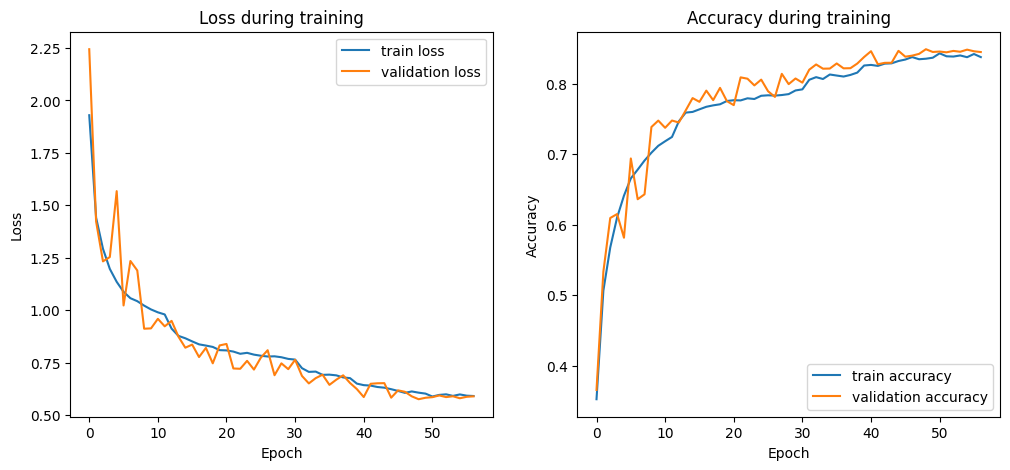

In [11]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy during training')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


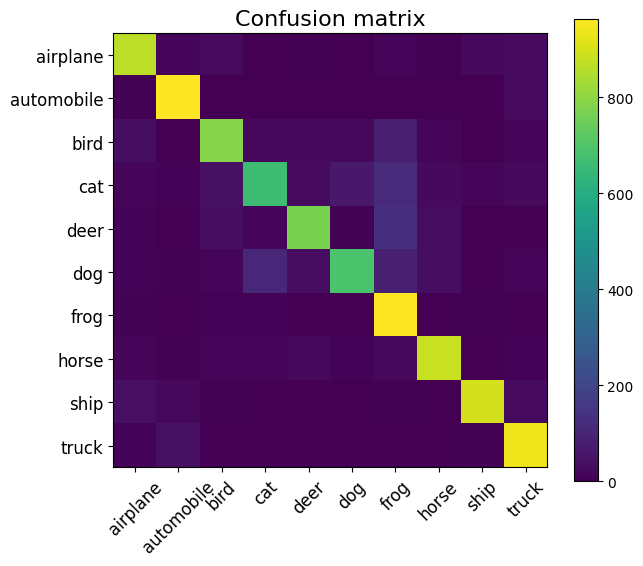

Test accuracy: 0.8416


In [12]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test_index, y_pred_test_classes))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1000
           1       0.90      0.96      0.93      1000
           2       0.83      0.79      0.81      1000
           3       0.79      0.66      0.72      1000
           4       0.87      0.77      0.82      1000
           5       0.87      0.69      0.77      1000
           6       0.68      0.96      0.79      1000
           7       0.88      0.88      0.88      1000
           8       0.94      0.90      0.92      1000
           9       0.86      0.94      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



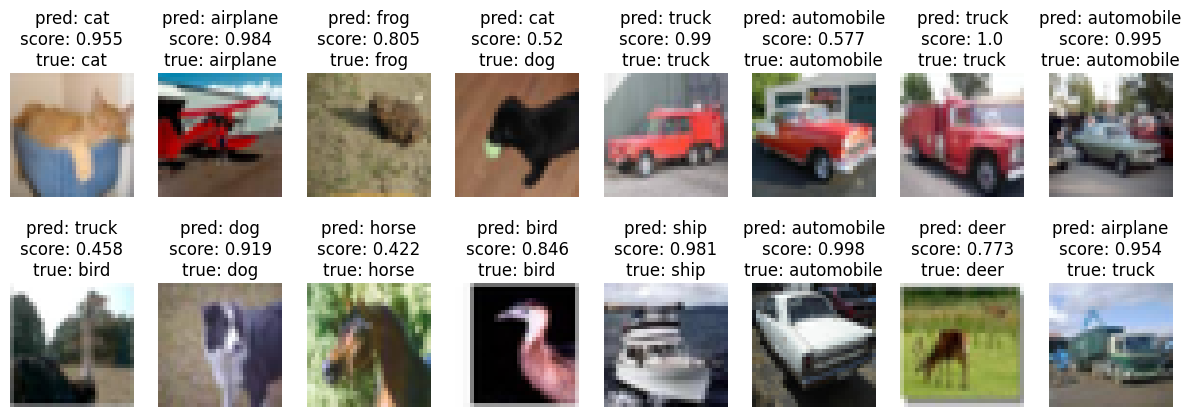

In [14]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Iteration Process of creating and improving CNN model for CIFAR-10


## Initial Architecture
The first version of the model was intended to be a minimal working model that can produce some output. It mainly followed the basic architecture suggested by orignial comments. The pattern concisted from convolutional layer with ReLU actinvation, max pooling  and fully connected layer. One convolution block was used for simplicity. The classifier concisted of a flattening operation followed by a dense layer with 64 neurons and a final softmax output layer for the ten CIFAR-10 classes.

Data preprocessing included normalisation of image values to [0, 1] range, splitting the original dataset into training, validation and test subsets. Conversion class labels into one-hot encoded vectors was introduced.

No regualrisation,  data augmentation was orignally used.




## Phylosophy of Improvements

 It is important to note that the actual improvements were produced note as eloquent and systematica as they will be described here. Here the general directions will be described and major steps will be listed with certain comments.

<br><br>


## Major directions
 ```
  1. Data augmentation
  2. Architecture expansion
  3. Experimentaion with optimisers, leraning rates, batch sizes
  4. Introducing different regularisation techniques
  5. Checking for overfitting
  6. Optimising learning speed  
 ```


###1. Data augmentation
 The original dataset contain clear room for improvement. We started from ImageDataGenerator aumentation technique(width/height shift range and horizontal flip) and changed it to the following layers:
 ```
keras.layers.RandomFlip("horizontal")
keras.layers.RandomTranslation(0.1, 0.1)
keras.layers.RandomRotation(0.05)
keras.layers.RandomZoom(0.1)
 ```
 Due to the fact that the origianl images are just 32x32  pixels it was not obious whether including zoom part was a good idea. But the final version does encorporate its mild version. Mild rotation was another improvement that used in the filal version of the model.

<br>

### 2. Architecture expansion
 The general direction here was from one hand to make networks deep enought but from the other hand not to make it too complicated to train on a single computer.

 The final accuracy in all the tries was somewhere between 81 - 85 %. At some point overfitting started to take place but more on that will be said in chapter 5. The final version of the model includes 3 convolutional blocks and a clasifier block. All considered 6 convolutional layers  was considered to be an optimal in order to first detect simple patterns such as edges, corners, and color contrasts, and then combine them to more complex features features such as shapes, textures, and object parts.

 During the creation of the model different different feature depth across blocks was tried:
 ```
 32 -> 64 -> 128
 ```

Introduction of Max-pooling allowed us to reduce the spatial size of the feature maps, which helped the model keep the most important information while making computation cheaper.

After extensive google sessions, reading different manuals and visiting kaagle site it was decided to imporove classifier structure by replaceing Flatten() with GlobalAveragePooling2D()

Among following different suggestions from the origianl file adding batch_normalization layers was a very handy for stabilizing trainng and speeding up convergence.


<br>

### 3. Experimentaion with optimisers, leraning rates, batch sizes and number of epochs
From the very beginning 1e-3 learning rate was used

Batch size was had either 32 or 64, but at the end of the 32 was used. 64 would give faster learning but we decided on 32 for the final version in the hope of improving accuracy. Once EarlyStopping was used the whole tradeof became less important.

Number of epoch was always in the region [40, 60] but to give me model more tries we decided to keep 60 for the final version

<br>

### 4. Introducing different regularisation techniques
Dropuot layers, L2 Weight Regularization were chosen for the final version.
Dropout allowed us to introduce stochastic noise during training which prevented coadaptation of neurons and L2  regularization constrained the magnitude of the weights.
Batch normalization was also used as a part of this process. It specifically allowed to stabilize and acceleratre training.

<br>

### 5. Checking for overfitting
When the overfitten became a possibility we decided to additionaly plot Loss and accuracy during traing. Indeed mild overfitting was detected this way. But once batch normalisation was properly intorduced the issue was resolved.


<br>

### 6. Optimising learning speed  

Some techniques like batch normalisation was already intruduced and described in details before. Another thing that was very useful for the optimiazation of of learning speed was the EarlyStopping technique.


<br><br><br>


## Final model  architecture
```
Input: (32×32×3)

-> Data Augmentation
   -> RandomFlip("horizontal")
   -> RandomTranslation(0.1, 0.1)
   -> RandomRotation(0.05)
   -> RandomZoom(0.1)

# Block 1
-> Conv2D(32, 3×3, padding='same', relu, L2)
-> BatchNormalization()
-> Conv2D(32, 3×3, padding='same', relu, L2)
-> BatchNormalization()
-> MaxPooling2D(2×2)
-> Dropout(0.25)

# Block 2
-> Conv2D(64, 3×3, padding='same', relu, L2)
-> BatchNormalization()
-> Conv2D(64, 3×3, padding='same', relu, L2)
-> BatchNormalization()
-> MaxPooling2D(2×2)
-> Dropout(0.30)

# Block 3
-> Conv2D(128, 3×3, padding='same', relu, L2)
-> BatchNormalization()
-> Conv2D(128, 3×3, padding='same', relu, L2)
-> BatchNormalization()
-> MaxPooling2D(2×2)
-> Dropout(0.35)

# Classifier
-> GlobalAveragePooling2D()
-> Dense(256, relu, L2)
-> BatchNormalization()
-> Dropout(0.5)
-> Dense(10, softmax)
```




<br><br>


## Final thoughts and future directions

The model successfully passed all evaluation tests and achieved an accuracy of approximately 84%. While this result is satisfactory, it remains below the current state-of-the-art performance for CIFAR-10 classification, which typically reaches 94–96% accuracy. Further improvements could potentially be achieved by exploring more advanced architectures and optimization strategies. However, training such models would likely require substantially more computational resources and training time, making the use of external computing infrastructure a practical consideration.   



# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.


